In [ ]:

import numpy as np
import pandas as pd
from pathlib import Path
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True, precision=4)

## Config

In [ ]:

# --------- DATA ----------
CSV_PATH = Path("Datasets and splits/Freegait/FreeGait/FreeGait/native_csv_export/kp3d_native_wide.csv")

# --------- SPLIT ----------
TEST_SESSION_RATIO = 0.20
SEED = 42
WINDOW_SIZE = 29    # in frames
OVERLAP = 14     # fraction of window size
# --------- SAMPLING / FILTER ----------
FPS = 10
FC  = 1.2
REMOVE_TRAJECTORY = True

# --------- DATA FILTERING ----------
MIN_SEQS_PER_PERSON = 50      # keep persons with >= this many sessions
MAX_SEQS_PER_PERSON = None    # optional cap to reduce imbalance

# --------- HMMLEARN HMM ----------
N_STATES = 6
N_ITER   = 50
TOL      = 1e-3
COV_TYPE = "diag"             # 'diag' is usually the most stable here
MIN_COVAR = 1e-4              # regularization / variance floor



In [4]:

df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
print("Unique persons:", df["person"].nunique())
print("Unique sessions:", df["sequence"].nunique())
df.head(3)

Shape: (238121, 76)
Unique persons: 1195
Unique sessions: 107


,person,device,sequence,frame,joint_pelvis_x,joint_pelvis_y,joint_pelvis_z,joint_left_hip_x,joint_left_hip_y,joint_left_hip_z,...,joint_left_wrist_z,joint_right_wrist_x,joint_right_wrist_y,joint_right_wrist_z,joint_left_hand_x,joint_left_hand_y,joint_left_hand_z,joint_right_hand_x,joint_right_hand_y,joint_right_hand_z
0,1,devid_1,seq_00_new,0,-5.403543,11.239110,-0.181148,-5.461105,11.279160,-0.272617,...,-0.219535,-5.174297,11.196809,-0.206083,-5.326843,11.465849,-0.288188,-5.141682,11.240250,-0.268160
1,1,devid_1,seq_00_new,1,-5.277913,11.312745,-0.176705,-5.334911,11.353487,-0.268222,...,-0.193586,-5.047028,11.314166,-0.185078,-5.245327,11.559608,-0.261631,-5.017918,11.369698,-0.238681
2,1,devid_1,seq_00_new,2,-5.167891,11.401410,-0.188302,-5.226202,11.440271,-0.279809,...,-0.214503,-4.932968,11.440286,-0.187356,-5.202204,11.646843,-0.288474,-4.908964,11.504774,-0.232848


In [6]:
from scipy.signal import butter, filtfilt

def winter_velocity (group,joints_col,fps,fc):
    pos = group[joints_col].to_numpy(dtype=np.float32)
    N, D = pos.shape
    dt = 1.0 / fps
    J = D // 3
        # --- 3D velocity first ---
    if N < 2:
        vel = np.zeros((N, D), dtype=np.float32)
    else:
        vel = np.gradient(pos, dt, axis=0).astype(np.float32)  # (N, 3J)
    # --- convert to speed per joint ---
    vel3 = vel.reshape(N, J, 3)                         # (N, J, 3)
    speed_raw = np.linalg.norm(vel3, axis=2).astype(np.float32)  # (N, J)
    # Butterworth low-pass for velocity w stands for 
    w = fc / (fps / 2.0)
    if not (0 < w < 1):
        raise ValueError(f"Bad cutoff: fc={fc} with fps={fps} gives normalized Wn={w} (must be in (0,1))")

    b, a = butter(N=2, Wn=w, btype="low")

    padlen = 3 * (max(len(a), len(b)) - 1)  # filtfilt requirement

    speed = filtfilt(b, a, speed_raw, axis=0) if N > padlen else speed_raw
    speed = speed.astype(np.float32)
    # filtfilt can fail on very short sequences; fall back to raw
        # labels: take every *_x col as joint base name
    joint_names = []
    for c in joints_col[::3]:
        parts = c.split("_")              # joint_left_knee_x
        joint_names.append("_".join(parts[1:-1]))  # left_knee
    speed_labels = [f"speed_{j}" for j in joint_names]
    return speed, speed_labels

In [7]:
import numpy as np

def fix_missdetected_joints(group, max_gap=500000, min_dup=4):
    #max gap for one second in this work because fps is 6
    """
    If, within the same frame, >= min_dup joints have EXACTLY the same (x,y,z),
    mark those joints as NaN and fill over time using linear interpolation.
    """
    joints = [
    "pelvis",
    "spine1", "spine2", "spine3",
    "neck", "head",

    "left_collar", "right_collar",
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "left_hand", "right_hand",
    "left_hip", "right_hip",
    "left_knee", "right_knee",
    "left_ankle", "right_ankle",
    "left_foot", "right_foot",

]

    #copy data frame 
    group = group.copy()
    #Build joint coordinate column names
    cols = [f"joint_{j}_{a}" for j in joints for a in "xyz"]
    #Convert to numpy and reshape to (T,J,3) where T is number of frames, J is number of joints
    arr = group[cols].to_numpy(float).reshape(len(group), len(joints), 3)
    #Mask for missdetected joints
    bad = np.zeros((len(group), len(joints)), dtype=bool)
    #Loop through each frame and find duplicates
    for t in range(len(group)):
        frame = arr[t]  # (J,3)
        #Ignore joints that already have NaNs in case it got used by CLS 
        valid = ~np.isnan(frame).any(axis=1)
        if valid.sum() < 2:
            continue

        # Find exact duplicate 3D coordinates in that frame
        uniq, inv, counts = np.unique(frame[valid], axis=0,
                                      return_inverse=True, return_counts=True)
        #Keep only coordinates repeated at least min_dup times
        dup_ids = np.where(counts >= min_dup)[0]
        if dup_ids.size == 0:
            continue
        #Mark those joints as bad
        dup_valid_mask = np.isin(inv, dup_ids)
        joint_idx = np.where(valid)[0][dup_valid_mask]
        joint_idx = joint_idx[joint_idx != torso_idx] # but never the torso
        bad[t, joint_idx] = True

    # Set duplicated joints to NaN (all 3 axes)
    arr[bad] = np.nan
    group.loc[:, cols] = arr.reshape(len(group), -1)

    # Fill from previous + next frames
    group.loc[:, cols] = (
        group.loc[:, cols]
             .interpolate(method="linear", limit=max_gap, limit_direction="both")
             .ffill(limit=max_gap)
             .bfill(limit=max_gap)
    )

    return group


In [8]:
import numpy as np

def angle_ABC(A, B, C, eps=1e-8):
    """
    Angle at B formed by points A-B-C.
    A,B,C: (T,3)
    returns: (T,1)
    """
    BA = A - B
    BC = C - B
    num = np.sum(BA * BC, axis=1, keepdims=True)
    den = (np.linalg.norm(BA, axis=1, keepdims=True) * np.linalg.norm(BC, axis=1, keepdims=True) + eps)
    cosang = np.clip(num / den, -1.0, 1.0)
    return np.arccos(cosang)  # radians

def get_joint_xyz(group, name):
    return group[[f"joint_{name}_x", f"joint_{name}_y", f"joint_{name}_z"]].to_numpy(dtype=np.float32)

def compute_angle_features(group, fps):
    pelvis = get_joint_xyz(group, "pelvis")
    spine3 = get_joint_xyz(group, "spine3")

    lh, lk, la = (get_joint_xyz(group, "left_hip"),
                  get_joint_xyz(group, "left_knee"),
                  get_joint_xyz(group, "left_ankle"))
    rh, rk, ra = (get_joint_xyz(group, "right_hip"),
                  get_joint_xyz(group, "right_knee"),
                  get_joint_xyz(group, "right_ankle"))

    ls, le, lw = (get_joint_xyz(group, "left_shoulder"),
                  get_joint_xyz(group, "left_elbow"),
                  get_joint_xyz(group, "left_wrist"))
    rs, re, rw = (get_joint_xyz(group, "right_shoulder"),
                  get_joint_xyz(group, "right_elbow"),
                  get_joint_xyz(group, "right_wrist"))

    # angles (T,1)
    knee_L = angle_ABC(lh, lk, la)
    knee_R = angle_ABC(rh, rk, ra)

    hip_L  = angle_ABC(pelvis, lh, lk)
    hip_R  = angle_ABC(pelvis, rh, rk)

    elbow_L = angle_ABC(ls, le, lw)
    elbow_R = angle_ABC(rs, re, rw)

    # simple trunk bend proxy: angle(pelvis–spine3–neck) 
    neck = get_joint_xyz(group, "neck")
    trunk = angle_ABC(pelvis, spine3, neck)

    ang = np.concatenate([knee_L, knee_R, hip_L, hip_R, elbow_L, elbow_R, trunk], axis=1)

    # angular velocity (finite diff)
    dang = np.vstack([np.zeros((1, ang.shape[1]), dtype=np.float32), np.diff(ang, axis=0)]) * fps

    feat = np.concatenate([ang, dang], axis=1).astype(np.float32)

    names = [
        "ang_knee_L","ang_knee_R","ang_hip_L","ang_hip_R","ang_elbow_L","ang_elbow_R","ang_trunk",
        "dang_knee_L","dang_knee_R","dang_hip_L","dang_hip_R","dang_elbow_L","dang_elbow_R","dang_trunk",
    ]
    return feat, names

In [9]:
import numpy as np

def make_windows(seq, label, window_size, step, pad_mode="edge"):
    """
    pad_mode:
      - "edge": repeat last frame 
      - "zero": pad with zeros
    """
    out_X, out_y = [], []
    T = len(seq)

    if T == 0:
        return out_X, out_y

    # If too short: pad and return exactly 1 window
    if T < window_size:
        seq = np.asarray(seq)
        pad_len = window_size - T

        if pad_mode == "edge":
            pad = np.repeat(seq[-1][None, :], pad_len, axis=0)
        elif pad_mode == "zero":
            pad = np.zeros((pad_len, seq.shape[1]), dtype=seq.dtype)
        else:
            raise ValueError("pad_mode must be 'edge' or 'zero'")

        win = np.vstack([seq, pad])
        out_X.append(win)
        out_y.append(label)
        return out_X, out_y

    # Normal sliding windows
    for start in range(0, T - window_size + 1, step):
        out_X.append(seq[start:start + window_size])
        out_y.append(label)

    return out_X, out_y


In [10]:
import numpy as np

def preprocess_features_split_native(
    df,
    window_size,
    overlap,
    test_session_ratio=0.20,
    seed=42,
    fps=10,
    fc=1.2,
    min_seqs_per_person=50,          # keep only persons with >= this many eligible sessions
    max_seqs_per_person=None,       # optional cap per person (helps balancing)
    remove_trajectory=True,         # pelvis-center before velocity/features
    use_padded_windows=False,       # if True, use make_windows_padded instead of make_windows
):
    """
    

    Returns:
      X_train: (Ntr, window_size, F)
      y_train: (Ntr,)
      X_test:  (Nts, window_size, F)
      y_test:  (Nts,)
      feat_cols: list[str]
    """

    # -------------------------------
    # 0) session_id
    # -------------------------------
    if "session_id" not in df.columns:
        df = df.copy()
        df["session_id"] = (
            df["person"].astype(str) + "-" +
            df["device"].astype(str) + "-" +
            df["sequence"].astype(str)
        )
    sess_per_person = (
            df.groupby("person")["session_id"]
          .nunique()
          .sort_values(ascending=False)
    )

    print("Sessions per person (top 20):")
    print(sess_per_person.head(20))

    print("\nSummary:")
    print(sess_per_person.describe())
    # persons with < MIN_SEQS_PER_PERSON
    print(f"\nPersons with < {MIN_SEQS_PER_PERSON} sessions:")
    print(sess_per_person[sess_per_person < MIN_SEQS_PER_PERSON].sort_values())                

    # -------------------------------
    # 1) columns / params
    # -------------------------------
    joint_cols = [
        c for c in df.columns
        if c.startswith("joint_") and c.endswith(("_x", "_y", "_z"))
    ]

    step = max(1, window_size - overlap)
    rng = np.random.default_rng(seed)

    # -------------------------------
    # 2) Build per-session feature sequences
    # -------------------------------
    sessions_by_person = {}  # person -> list of (session_id, feats[T,F])
    feat_cols = None
   
    grouped = df.groupby(["person", "session_id"], sort=False)

    for (person, session_id), group in grouped:
        group = group.sort_values("frame").reset_index(drop=True).copy()
        
        group = fix_missdetected_joints(group, max_gap=20, min_dup=2)

        group = group.dropna(subset=joint_cols).reset_index(drop=True)

        if len(group) == 0:
            continue

        # optional: remove trajectory by pelvis-centering each frame
        if remove_trajectory:
            for ax in ("x", "y", "z"):
                pel = group[f"joint_pelvis_{ax}"].to_numpy()
                cols_ax = [c for c in joint_cols if c.endswith(f"_{ax}")]
                group.loc[:, cols_ax] = group.loc[:, cols_ax].to_numpy() - pel[:, None]

        # --- your feature functions ---
        vel, vel_col_names = winter_velocity(group, joint_cols, fps, fc)
        
        ang_feat, ang_names = compute_angle_features(group, fps)
        T =vel.shape[0]
        feats = np.concatenate([ vel,ang_feat], axis=1).astype(np.float32)

        # skip bad sessions
        if feats.shape[0] == 0 or np.isnan(feats).any():
            continue

        if feat_cols is None:
            feat_cols =  vel_col_names+ang_names

        sessions_by_person.setdefault(str(person), []).append((str(session_id), feats))
        
    # nothing usable
    if feat_cols is None:
        return (
            np.empty((0, window_size, 0), dtype=np.float32),
            np.empty((0,), dtype=object),
            np.empty((0, window_size, 0), dtype=np.float32),
            np.empty((0,), dtype=object),
            [],
        )

    # -------------------------------
    # 3) Split sessions per person -> window samples
    # -------------------------------
    X_train, y_train, X_test, y_test = [], [], [], []
    kept_people = 0
    dropped_people = 0

    # choose which windowing function to use
    if use_padded_windows:
        win_fn = make_windows_padded  
    else:
        win_fn = make_windows        

    for person, sess_list in sessions_by_person.items():
        # eligible sessions that can produce at least one window unless in padding
        if use_padded_windows:
            eligible = sess_list[:]  # padding makes all sessions eligible (except empty)
        else:
            eligible = [(sid, feats) for (sid, feats) in sess_list if len(feats) >= window_size]
    
        n = len(eligible)
        if n == 0:
            continue

        # filter persons by number of eligible sessions
        if n < min_seqs_per_person:
            dropped_people += 1
            continue

        # optional cap to reduce imbalance
        if max_seqs_per_person is not None and n > max_seqs_per_person:
            eligible.sort(key=lambda x: x[0])  # deterministic
            eligible = eligible[:max_seqs_per_person]
            n = len(eligible)

        kept_people += 1

        # if only one eligible session, put it in train
        if n == 1:
            sid, feats = eligible[0]
            Xtr, ytr = win_fn(feats, person, window_size, step)
            X_train.extend(Xtr); y_train.extend(ytr)
            continue

        # choose test sessions
        n_test = int(np.ceil(n * test_session_ratio))
        n_test = max(1, min(n_test, n - 1))  # at least 1 test and 1 train

        # deterministic order before random split
        eligible.sort(key=lambda x: x[0])
        perm = rng.permutation(n)
        test_idx = set(perm[:n_test].tolist())

        for i, (sid, feats) in enumerate(eligible):
            if i in test_idx:
                Xts, yts = win_fn(feats, person, window_size, step)
                X_test.extend(Xts); y_test.extend(yts)
            else:
                Xtr, ytr = win_fn(feats, person, window_size, step)
                X_train.extend(Xtr); y_train.extend(ytr)
       
    print(f"[split] kept persons={kept_people}, dropped persons={dropped_people}")
    print(f"[split] train windows={len(X_train)}, test windows={len(X_test)}")

    return (
        np.asarray(X_train, dtype=np.float32),
        np.asarray(y_train),
        np.asarray(X_test, dtype=np.float32),
        np.asarray(y_test),
        feat_cols,
    )


# -------------------------------
# Optional: padded windowing 
# -------------------------------
def make_windows_padded(seq, label, window_size, step, pad_mode="edge"):
    """
    Like make_windows, but if len(seq) < window_size it pads and returns exactly 1 window.
    """
    out_X, out_y = [], []
    seq = np.asarray(seq)
    T = len(seq)

    if T == 0:
        return out_X, out_y

    if T < window_size:
        pad_len = window_size - T
        if pad_mode == "edge":
            pad = np.repeat(seq[-1][None, :], pad_len, axis=0)
        elif pad_mode == "zero":
            pad = np.zeros((pad_len, seq.shape[1]), dtype=seq.dtype)
        else:
            raise ValueError("pad_mode must be 'edge' or 'zero'")
        win = np.vstack([seq, pad])
        out_X.append(win)
        out_y.append(label)
        return out_X, out_y

    for start in range(0, T - window_size + 1, step):
        out_X.append(seq[start:start + window_size])
        out_y.append(label)

    return out_X, out_y


In [11]:

X_train_seq, y_train, X_test_seq, y_test, feat_cols = preprocess_features_split_native(df,fps=FPS,fc=FC,window_size=WINDOW_SIZE,overlap=OVERLAP,min_seqs_per_person=50)


print("Train sessions:", len(X_train_seq), "Test sessions:", len(X_test_seq))
print("Feature dim F:", X_train_seq[0].shape[1])

Sessions per person (top 20):
person
1191    84
1206    55
1235    54
1150    50
1194    50
1229    50
1165    50
1199    49
1178    48
1205    48
1212    48
1234    46
1151    46
1208    46
1153    44
1196    44
1168    44
1197    43
1250    42
1180    42
Name: session_id, dtype: int64

Summary:
count    1195.000000
mean        9.975732
std         8.332712
min         1.000000
25%         5.000000
50%         8.000000
75%        13.000000
max        84.000000
Name: session_id, dtype: float64

Persons with < 50 sessions:
person
15       1
16       1
288      1
1218     1
847      1
        ..
1208    46
1205    48
1212    48
1178    48
1199    49
Name: session_id, Length: 1188, dtype: int64
[split] kept persons=7, dropped persons=613
[split] train windows=350, test windows=85
Train sessions: 350 Test sessions: 85
Feature dim F: 38


In [12]:

def fit_standardizer(seqs):
    X = np.concatenate(seqs, axis=0)
    mu = X.mean(axis=0)
    sd = X.std(axis=0) + 1e-6
    return mu.astype(np.float32), sd.astype(np.float32)

def apply_standardizer(seqs, mu, sd):
    return [((s - mu) / sd).astype(np.float32) for s in seqs]

mu, sd = fit_standardizer(X_train_seq)
X_train_seq_n = apply_standardizer(X_train_seq, mu, sd)
X_test_seq_n  = apply_standardizer(X_test_seq,  mu, sd)

print("Standardized: train[0] mean/std approx:",
      X_train_seq_n[0].mean(), X_train_seq_n[0].std())

Standardized: train[0] mean/std approx: 0.019777415 0.767525


In [13]:
import numpy as np
from collections import defaultdict
import zlib

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from hmmlearn.hmm import GaussianHMM
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report


# -----------------------------
# deterministic per-person seed helper
# -----------------------------
def pid_seed(pid) -> int:
    # stable across runs (unlike Python's built-in hash)
    return int(zlib.crc32(str(pid).encode("utf-8")) & 0xFFFFFFFF)


# -----------------------------
# HMM training helpers
# -----------------------------
def fit_hmm_best_of(seqs, *, n_states, cov_type, n_iter, tol, min_covar, n_restarts, seed_base):
    X_concat = np.vstack(seqs)
    lengths = [len(s) for s in seqs]

    best_model, best_ll = None, -np.inf

    for r in range(n_restarts):
        model = GaussianHMM(
            n_components=n_states,
            covariance_type=cov_type,
            n_iter=n_iter,
            tol=tol,
            min_covar=min_covar,
            random_state=seed_base + 1000 * r,
            verbose=False,
        )
        model.fit(X_concat, lengths)
        ll = model.score(X_concat, lengths)

        if ll > best_ll:
            best_ll = ll
            best_model = model

    return best_model, best_ll


def train_person_models(X_seqs, y, *, n_states, cov_type, n_iter, tol, min_covar, n_restarts, seed_base):
    by_person = defaultdict(list)
    for X, pid in zip(X_seqs, y):
        by_person[pid].append(X)

    persons = sorted(by_person.keys())
    models = {}

    for pid in persons:
        model, _ = fit_hmm_best_of(
            by_person[pid],
            n_states=n_states,
            cov_type=cov_type,  
            n_iter=n_iter,
            tol=tol,
            min_covar=min_covar,
            n_restarts=n_restarts,
            seed_base=seed_base + (pid_seed(pid) % 100_000),
        )
        models[pid] = model

    return persons, models


c:\Users\49157\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
def predict_sessions(persons, models, X_seqs):
    ypred = []
    for X in X_seqs:
        scores = [models[pid].score(X) for pid in persons]
        ypred.append(persons[int(np.argmax(scores))])
    return np.asarray(ypred, dtype=object)


In [ ]:
# Precompute multiple stratified splits (fixed across trials)
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold


SEED = 42
VAL_RATIO = 0.2
N_SPLITS = 10  # increase to 10 for more stability (slower)

y_all = np.asarray(y_train, dtype=object)
idx = np.arange(len(y_all))

sss = StratifiedKFold(
    n_splits=N_SPLITS,
    random_state=SEED,
    shuffle=True,
)

splits = []
for tr_idx, va_idx in sss.split(idx, y_all):
    splits.append((tr_idx, va_idx))


# -----------------------------
# Optuna objective: mean f1 over splits
# -----------------------------
def objective(trial: optuna.Trial):
    n_states  = trial.suggest_int("n_states", 2, 16)
    cov_type  = trial.suggest_categorical("cov_type", ["diag", "full"])
    n_iter    = trial.suggest_int("n_iter", 30, 200)
    tol       = trial.suggest_float("tol", 1e-4, 1e-2, log=True)
    min_covar = trial.suggest_float("min_covar", 1e-6, 1e-3, log=True)
    n_restarts = trial.suggest_int("n_restarts", 1, 5)

    f1s = []

    for split_i, (tr_idx, va_idx) in enumerate(splits):
        Xtr = [X_train_seq_n[i] for i in tr_idx]
        ytr = y_all[tr_idx]
        Xva = [X_train_seq_n[i] for i in va_idx]
        yva = y_all[va_idx]

        try:
            persons, models = train_person_models(
                Xtr, ytr,
                n_states=n_states,
                cov_type=cov_type,
                n_iter=n_iter,
                tol=tol,
                min_covar=min_covar,
                n_restarts=n_restarts,
                seed_base=SEED + 100 * split_i,   # change seed per split
            )

            ypred = predict_sessions(persons, models, Xva)
            f1 = f1_score(yva, ypred, average='macro')

        except Exception:
            # if a hyperparam combo makes training blow up, treat as bad
            f1 = 0.0
        f1s.append(f1)

        # report running mean for pruning
        running_mean = float(np.mean(f1))
        trial.report(running_mean, step=split_i)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(f1s))


# Run study
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=10),
)

study.optimize(objective, n_trials=25, show_progress_bar=True)

print("Best mean val f1:", study.best_value)
print("Best params:", study.best_params)


[I 2026-01-12 23:54:12,283] A new study created in memory with name: no-name-ab1096bf-a0d3-42a4-8034-9079584c4f58
  0%|          | 0/25 [00:00<?, ?it/s]

Model is not converging.  Current: -60084.903395159905 is not greater than -60084.89863403731. Delta is -0.004761122596391942
Best trial: 0. Best value: 0.76:   4%|▍         | 1/25 [01:51<44:46, 111.94s/it]

[I 2026-01-12 23:56:04,226] Trial 0 finished with value: 0.76 and parameters: {'n_states': 7, 'cov_type': 'diag', 'n_iter': 132, 'tol': 0.0002051338263087451, 'min_covar': 2.9375384576328313e-06, 'n_restarts': 1}. Best is trial 0 with value: 0.76.


Model is not converging.  Current: 15597.545943845114 is not greater than 15910.252079040576. Delta is -312.7061351954617
Model is not converging.  Current: 19741.005669161557 is not greater than 20068.656391111104. Delta is -327.650721949547
Model is not converging.  Current: 18169.048564456276 is not greater than 18718.307988922334. Delta is -549.2594244660577
Model is not converging.  Current: 19048.4509390685 is not greater than 19411.611918778504. Delta is -363.1609797100027
Model is not converging.  Current: 20873.899040161785 is not greater than 21621.94047220116. Delta is -748.0414320393756
Model is not converging.  Current: 26333.611192811837 is not greater than 27403.272506955647. Delta is -1069.6613141438102
Model is not converging.  Current: 16238.765764631618 is not greater than 17013.656807855594. Delta is -774.8910432239754
Model is not converging.  Current: 14315.571166940907 is not greater than 14855.893258619579. Delta is -540.3220916786722
Model is not converging.  C

[I 2026-01-13 00:17:57,814] Trial 1 finished with value: 0.7599999999999999 and parameters: {'n_states': 14, 'cov_type': 'full', 'n_iter': 33, 'tol': 0.008706020878304856, 'min_covar': 0.0003142880890840109, 'n_restarts': 2}. Best is trial 0 with value: 0.76.


...

[I 2026-01-13 06:00:09,743] Trial 22 finished with value: 0.9457142857142857 and parameters: {'n_states': 4, 'cov_type': 'full', 'n_iter': 96, 'tol': 0.00544715079930034, 'min_covar': 3.4984224732336324e-06, 'n_restarts': 3}. Best is trial 3 with value: 0.9485714285714286.


Best trial: 3. Best value: 0.948571:  96%|█████████▌| 24/25 [6:14:04<11:59, 719.69s/it]

[I 2026-01-13 06:08:16,663] Trial 23 finished with value: 0.9457142857142857 and parameters: {'n_states': 3, 'cov_type': 'full', 'n_iter': 131, 'tol': 0.0014702926776764256, 'min_covar': 1.088347924473069e-06, 'n_restarts': 2}. Best is trial 3 with value: 0.9485714285714286.


Best trial: 3. Best value: 0.948571: 100%|██████████| 25/25 [6:16:52<00:00, 904.49s/it]

[I 2026-01-13 06:11:04,603] Trial 24 pruned. 
Best mean val acc: 0.9485714285714286
Best params: {'n_states': 4, 'cov_type': 'full', 'n_iter': 107, 'tol': 0.0037183641805732083, 'min_covar': 3.972110727381911e-06, 'n_restarts': 3}


## Confusion matrix

In [ ]:

# Retrain on FULL train with best params, then test

best = study.best_params

persons_best, models_best = train_person_models(
    X_train_seq_n, np.asarray(y_train, dtype=object),
    n_states=best["n_states"],
    cov_type=best["cov_type"],
    n_iter=best["n_iter"],
    tol=best["tol"],
    min_covar=best["min_covar"],
    n_restarts=best["n_restarts"],
    seed_base=SEED,
)

y_pred_test = predict_sessions(persons_best, models_best, X_test_seq_n)
acc_test = accuracy_score(y_test, y_pred_test)

print("\nSession-level TEST accuracy:", acc_test)
print("\nClassification report:")
print(classification_report(y_test, y_pred_test, zero_division=0))


Session-level TEST accuracy: 0.9647058823529412

Classification report:
              precision    recall  f1-score   support

        1150       0.92      1.00      0.96        11
        1165       1.00      0.90      0.95        10
        1191       0.95      0.95      0.95        21
        1194       0.91      1.00      0.95        10
        1206       1.00      1.00      1.00        11
        1229       1.00      1.00      1.00        11
        1235       1.00      0.91      0.95        11

    accuracy                           0.96        85
   macro avg       0.97      0.97      0.97        85
weighted avg       0.97      0.96      0.96        85



In [ ]:

# 1) Confusion matrices (counts and row-normalized %)
import numpy as np
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
 


def plot_confusion_matrices(y_true, y_pred, savepath=None, title_prefix="Confusion Matrix", ):
    labels_present = sorted(set(y_true) | set(y_pred), key=str)
    cm = confusion_matrix(y_true, y_pred, labels=labels_present)

    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums!=0)

    n_cls = len(labels_present)
    fig_w = max(12, 0.7 * n_cls + 8)
    fig_h = max(6,  0.7 * n_cls + 3)

    fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h), constrained_layout=True)
    fig.set_dpi(150)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True,
                linewidths=0.5, linecolor="white",
                xticklabels=[str(l) for l in labels_present],
                yticklabels=[str(l) for l in labels_present],
                annot_kws={"size": 12}, ax=axes[0])
    axes[0].set_title(f"{title_prefix} (counts)")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

    sns.heatmap(cm_norm*100, annot=True, fmt=".1f", cmap="Reds", cbar=True, vmin=0, vmax=100, square=True,
                linewidths=0.5, linecolor="white",
                xticklabels=[str(l) for l in labels_present],
                yticklabels=[str(l) for l in labels_present],
                annot_kws={"size": 12}, ax=axes[1])
    axes[1].set_title(f"{title_prefix} (row-normalized, %)")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

    for ax in axes:
        for lbl in ax.get_xticklabels():
            lbl.set_rotation(45); lbl.set_ha("right"); lbl.set_fontsize(10)
        for lbl in ax.get_yticklabels():
            lbl.set_fontsize(10)

    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        fig.savefig(savepath, dpi=300)
        print(f"Saved confusion matrices to {savepath}")

    plt.show()

# 2) Per-class metrics bar chart
def plot_per_class_report(y_true, y_pred, labels=None, digits=3):
    rep = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    classes = [k for k in rep.keys() if k not in ('accuracy','macro avg','weighted avg')]
    metrics = ['precision','recall','f1-score']
    data = np.array([[rep[c][m] for c in classes] for m in metrics])
    fig, ax = plt.subplots(figsize=(8,4))
    x = np.arange(len(classes))
    w = 0.25
    for i,m in enumerate(metrics):
        ax.bar(x + (i-1)*w, data[i], width=w, label=m)
    ax.set_xticks(x); ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_ylim(0,1); ax.set_ylabel('score'); ax.set_title('Per-class metrics')
    ax.legend(); plt.tight_layout()


Saved confusion matrices to figs/cm_test.png


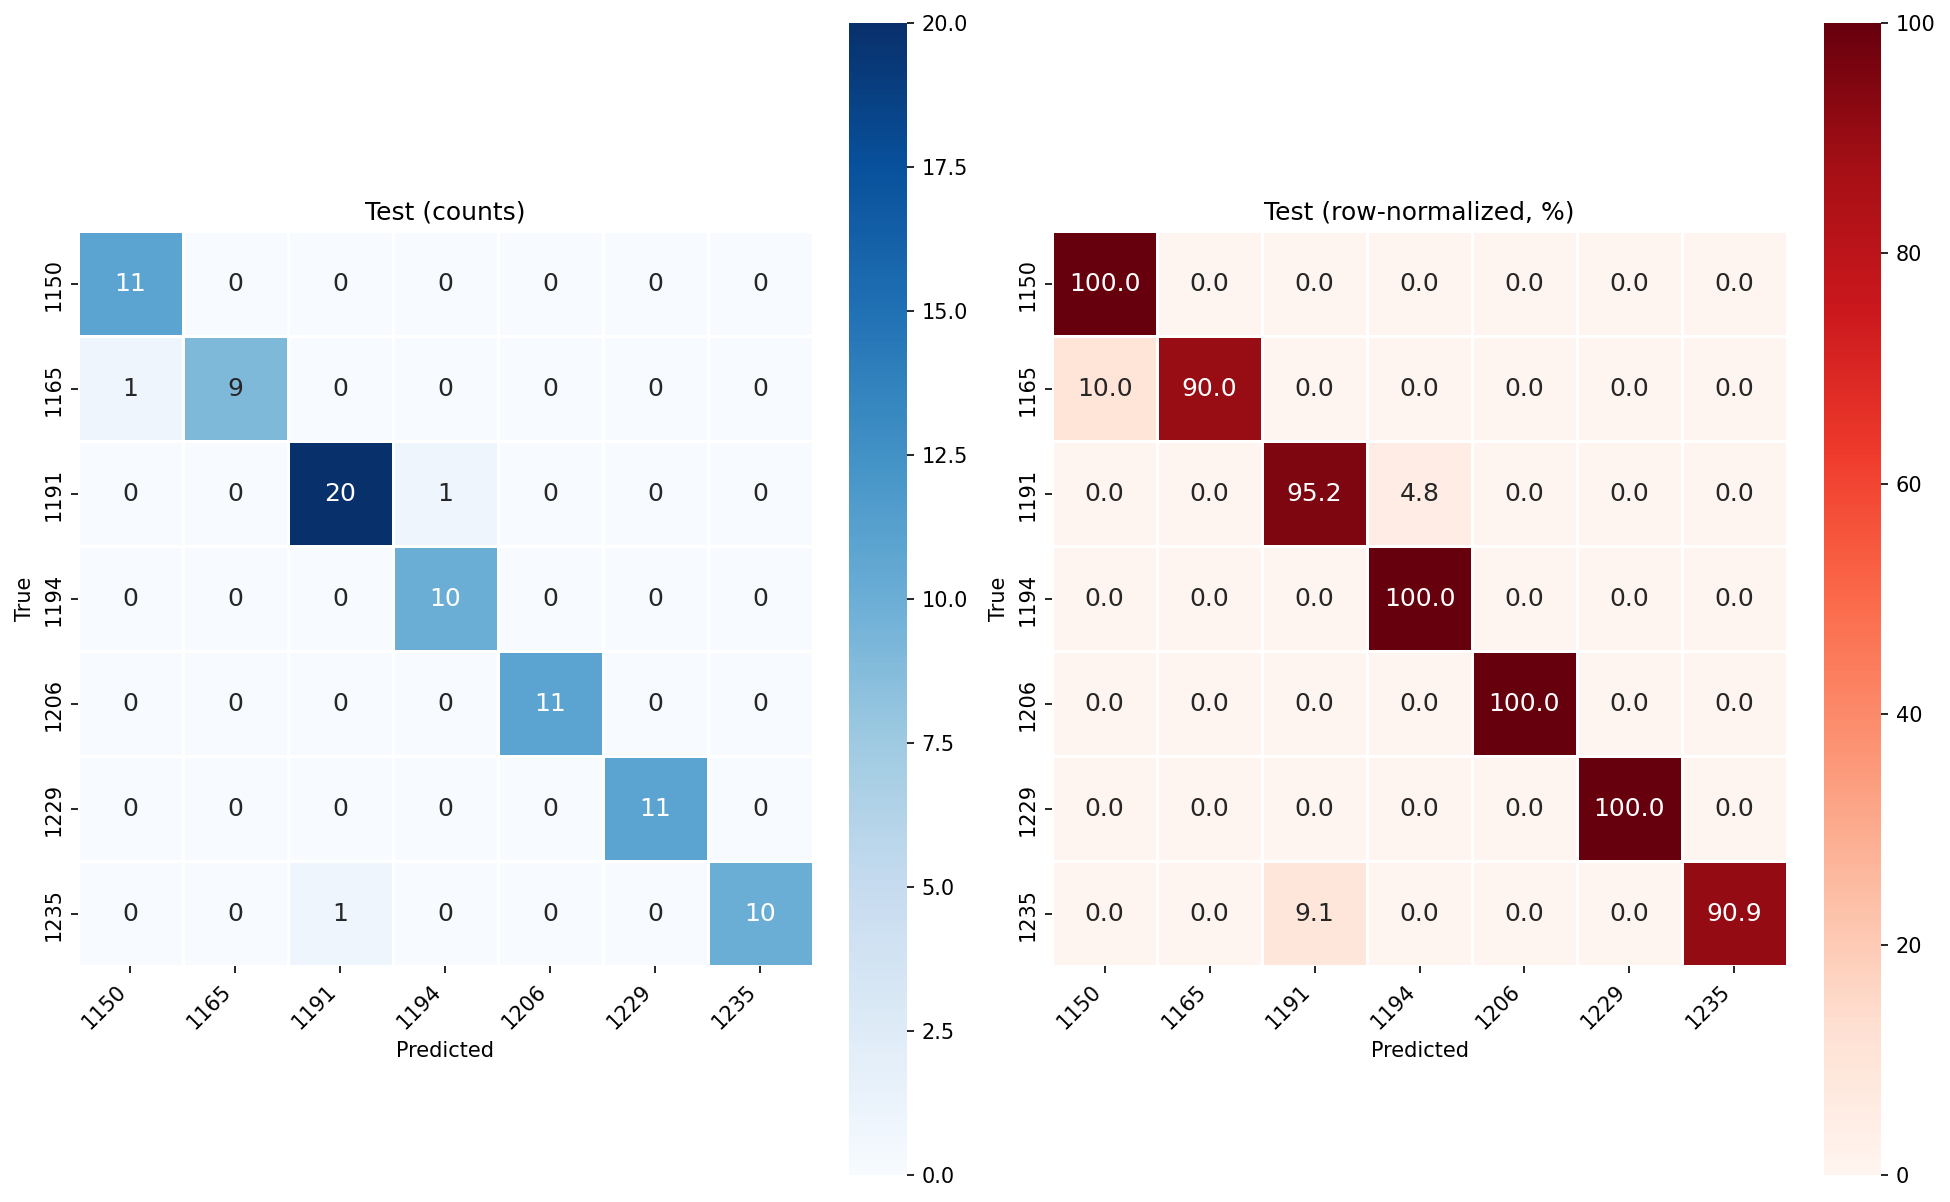

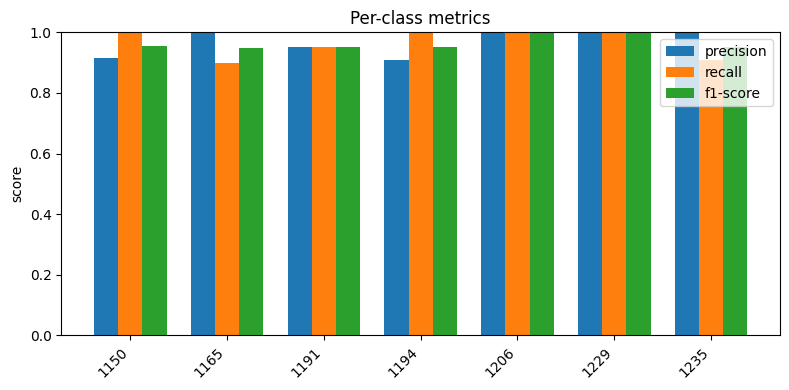

In [ ]:
# 1) Confusion matrices (both y_true and y_pred are strings)
plot_confusion_matrices(y_test, y_pred_test, savepath="figs/cm_test.png", title_prefix="Test")

# 2) Per-class precision/recall/F1 bars
plot_per_class_report(y_test, y_pred_test)
import os

## Choosing `N_STATES` (quick grid)
For person-ID, pick the number of states that maximizes **validation session accuracy** (split by session).
A simple start is `K ∈ {3,4,5,6,8,10}`.

In [ ]:

from sklearn.model_selection import StratifiedShuffleSplit

def stratified_train_val_split(X_seqs, y, val_ratio=0.2, seed=42):
    y = np.asarray(y, dtype=object)
    idx = np.arange(len(y))
    sss = StratifiedShuffleSplit(n_splits=10, test_size=val_ratio, random_state=seed)
    tr_idx, va_idx = next(sss.split(idx, y))
    Xtr = [X_seqs[i] for i in tr_idx]
    ytr = y[tr_idx]
    Xva = [X_seqs[i] for i in va_idx]
    yva = y[va_idx]
    return Xtr, ytr, Xva, yva

Xtr, ytr, Xva, yva = stratified_train_val_split(X_train_seq_n, y_train, val_ratio=0.2, seed=SEED)

def train_models_for_K(Xtr, ytr, K):
    by_person = defaultdict(list)
    for X, pid in zip(Xtr, ytr):
        by_person[pid].append(X)
    persons = sorted(by_person.keys())
    models = {}
    for pid in persons:
        models[pid], _ = fit_hmm_best_of(
            by_person[pid],
            n_states=K,
            cov_type=COV_TYPE,
            n_iter=N_ITER,
            tol=TOL,
            min_covar=MIN_COVAR,
            n_restarts=max(1, N_RESTARTS//2),
            seed_base=SEED + 17,
        )
    return persons, models

def eval_models(persons, models, Xva, yva):
    ypred = []
    for X in Xva:
        scores = [models[pid].score(X) for pid in persons]
        ypred.append(persons[int(np.argmax(scores))])
    return accuracy_score(yva, np.array(ypred, dtype=object))

Ks = [3,4,5,6,8,10]
results = []
for K in Ks:
    persons_k, models_k = train_models_for_K(Xtr, ytr, K)
    acc_k = eval_models(persons_k, models_k, Xva, yva)
    results.append((K, acc_k))
    print("K =", K, "val_acc =", acc_k)

bestK = max(results, key=lambda t: t[1])[0]
print("\nBest K by val acc:", bestK)

K = 3 val_acc = 0.6428571428571429
K = 4 val_acc = 0.6428571428571429
K = 5 val_acc = 0.6857142857142857
K = 6 val_acc = 0.7
K = 8 val_acc = 0.7428571428571429
K = 10 val_acc = 0.7428571428571429

Best K by val acc: 8
